# LLM-Assisted Alignment Pipeline

Pipeline semi-automatizado para alinear metadata de SRA con información suplementaria de papers.

## Flujo por paper:
1. **RAG sobre el paper** → identifica qué suplementario contiene qué información
2. **Inspección de suplementarios** → carga muestra de contenido
3. **LLM detecta columnas** → decide qué columnas usar para el join
4. **Ejecución** → produce `metadata.updated.csv`, guarda dieta, registra links
5. **Registro** → todo queda en `alignment_config.json`

## Modelo: `openai/gpt-4o-mini` vía OpenRouter

In [ ]:
!pip install pandas openpyxl python-dotenv openai requests -q

In [1]:
import os
import json
import re
import zipfile
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd
from openai import OpenAI

# Cargar API key desde .env
load_dotenv()
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY')
assert OPENROUTER_API_KEY, 'No se encontró OPENROUTER_API_KEY en el archivo .env'

# Cliente OpenRouter
client = OpenAI(
    base_url='https://openrouter.ai/api/v1',
    api_key=OPENROUTER_API_KEY,
)
MODEL =  'openai/gpt-4o-mini'

# Rutas del proyecto
PROJECT_DIR  = Path('.').resolve()
SRA_DIR      = PROJECT_DIR / 'data' / 'PMID_Bioproject_SRAmetadata'
RAW_DIR      = PROJECT_DIR / 'data' / 'raw'
ALIGNED_DIR  = PROJECT_DIR / 'data' / 'aligned'
DIET_DIR     = PROJECT_DIR / 'data' / 'diet'
CONFIG_PATH  = PROJECT_DIR / 'alignment_config.json'
EXCEL_PATH   = PROJECT_DIR / 'tabla_estudios.xlsx'

for d in [ALIGNED_DIR, DIET_DIR]:
    d.mkdir(parents=True, exist_ok=True)

alignment_config = json.loads(CONFIG_PATH.read_text()) if CONFIG_PATH.exists() else {}

print(f'Configuracion lista — Modelo: {MODEL}')
print(f'Papers ya procesados: {len(alignment_config)}')

Configuracion lista — Modelo: openai/gpt-4o-mini
Papers ya procesados: 9


## Utilidades de carga de archivos

In [2]:
def load_sra_csv(pmid, bioproject):
    patterns = [
        SRA_DIR / f'{pmid}_{bioproject}_metadata.csv',
        SRA_DIR / f'{pmid}_{bioproject}.csv',
        SRA_DIR / f'{bioproject}_metadata.csv',
    ]
    for p in patterns:
        if p.exists():
            return pd.read_csv(p, dtype=str)
    return None


def has_multirow_header(df):
    """
    Detecta si un DataFrame tiene header de multiples filas.
    Criterio: mas del 50% de columnas son 'Unnamed'.
    """
    unnamed_count = sum(1 for c in df.columns if str(c).startswith('Unnamed'))
    return unnamed_count / len(df.columns) > 0.5


def load_tabular_file(path, header_row=0):
    """
    Carga un archivo tabular. Si detecta header multiple (>50% columnas Unnamed),
    itera incrementando header_row hasta encontrar el header real o llegar a fila 4.
    """
    def _read(hr):
        try:
            if path.suffix in ('.xlsx', '.xls'):
                return pd.read_excel(path, header=hr, dtype=str)
            elif path.suffix == '.tsv':
                return pd.read_csv(path, sep='\t', header=hr, dtype=str)
            elif path.suffix == '.txt':
                try:
                    return pd.read_csv(path, sep='\t', header=hr, dtype=str)
                except Exception:
                    return pd.read_csv(path, header=hr, dtype=str)
            else:
                return pd.read_csv(path, header=hr, dtype=str)
        except Exception as e:
            print(f'  No se pudo cargar {path.name} con header={hr}: {e}')
            return None

    df = _read(header_row)
    if df is None:
        return None

    # Iterar hasta encontrar header sin Unnamed o hasta fila 4
    current_row = header_row
    while has_multirow_header(df) and current_row < 4:
        current_row += 1
        print(f'    Header multiple detectado. Reintentando con header={current_row}...')
        new_df = _read(current_row)
        if new_df is None:
            break
        df = new_df

    if has_multirow_header(df):
        print(f'    Aviso: no se encontro header limpio hasta fila 4. Usando header={current_row}.')

    return df


def is_raw_format(path):
    raw_ext = {'.bed', '.bim', '.fam', '.vcf', '.gz', '.h5', '.hdf5', '.raw', '.nof'}
    if path.suffix in raw_ext:
        return True
    if path.suffix == '.zip':
        try:
            with zipfile.ZipFile(path) as z:
                return any(Path(n).suffix in raw_ext for n in z.namelist())
        except Exception:
            pass
    return False


def find_supplementary_files(pmid):
    raw_pmid = RAW_DIR / pmid
    if not raw_pmid.exists():
        return []
    patterns = ['**/*.csv','**/*.xlsx','**/*.xls','**/*.tsv','**/*.txt','**/*.zip','**/*.bed','**/*.vcf']
    files = []
    for pat in patterns:
        files.extend(raw_pmid.glob(pat))
    return sorted(set(files))


def read_paper_text(pmid, max_chars=8000):
    raw_pmid = RAW_DIR / pmid
    candidates = list(raw_pmid.glob('**/*.txt')) + list(raw_pmid.glob('**/*.nxml')) if raw_pmid.exists() else []
    texts_dir = PROJECT_DIR / 'data' / 'papers_txt'
    if texts_dir.exists():
        candidates += list(texts_dir.glob(f'*{pmid}*.txt'))
    for c in candidates:
        try:
            text = c.read_text(encoding='utf-8', errors='ignore')
            if len(text) > 500:
                return text[:max_chars]
        except Exception:
            pass
    return None


def get_table_sample(df, n_rows=5):
    return df.head(n_rows).to_string(index=False, max_cols=20)


print('Utilidades cargadas')

Utilidades cargadas


## Funciones LLM

Tres llamadas al LLM, cada una con una responsabilidad específica.

In [3]:
def llm_call(system_prompt, user_prompt):
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {'role': 'system', 'content': system_prompt},
            {'role': 'user',   'content': user_prompt}
        ],
        temperature=0,
        max_tokens=1000,
    )
    return response.choices[0].message.content.strip()


def llm_parse_paper(paper_text, supp_file_names):
    system = (
        'You are a scientific data extraction assistant. '
        'Analyze a scientific paper and identify what each supplementary file contains. '
        'Respond ONLY with a valid JSON object, no additional text.'
    )
    user = (
        f'Supplementary files available: {json.dumps(supp_file_names)}\n\n'
        f'Paper text:\n---\n{paper_text}\n---\n\n'
        'Respond with JSON:\n'
        '{\n'
        '  "supplementary_map": [\n'
        '    {\n'
        '      "filename": "exact filename",\n'
        '      "data_type": "animal_data|diet_data|genotype|metabolomics|microbiome|other_raw|unknown",\n'
        '      "description": "brief description",\n'
        '      "key_column_hint": "column name that identifies samples, or null",\n'
        '      "action": "join_with_sra|save_as_link|extract_text|skip"\n'
        '    }\n'
        '  ],\n'
        '  "diet_in_methods": true or false\n'
        '}'
    )
    raw = llm_call(system, user)
    raw = re.sub(r'```json|```', '', raw).strip()
    return json.loads(raw)


def llm_detect_join_columns(df_sra, df_supp, supp_filename):
    """
    Detecta columnas de join entre SRA y suplementario.
    Usa few-shot examples para guiar al LLM hacia joins correctos.
    """
    system = (
        'You are a data integration expert working with genomics metadata. '
        'Your task is to identify if two tables share a common sample identifier '
        'that allows them to be joined. '
        'Respond ONLY with a valid JSON object, no additional text.'
    )

    def col_sample(series, n=5):
        return series.dropna().astype(str).head(n).tolist()

    # Calcular overlap real entre cada columna de SRA y cada columna del suplementario
    # Esto permite al LLM ver evidencia concreta de coincidencia sin depender
    # de que las primeras filas de muestra tengan valores solapados
    def compute_overlap(df1, df2, max_cols=999):
        overlaps = []
        for col1 in df1.columns[:max_cols]:
            set1 = set(df1[col1].dropna().astype(str).unique())
            for col2 in df2.columns[:max_cols]:
                set2 = set(df2[col2].dropna().astype(str).unique())
                common = set1 & set2
                if common:
                    overlaps.append({
                        'col_sra': col1,
                        'col_supp': col2,
                        'overlap_count': len(common),
                        'examples': sorted(list(common))[:5]
                    })
        # Ordenar por overlap descendente
        overlaps.sort(key=lambda x: x['overlap_count'], reverse=True)
        return overlaps[:5]  # Top 5 pares con mas overlap

    sra_sample_values = {col: col_sample(df_sra[col]) for col in df_sra.columns}
    supp_sample_values = {col: col_sample(df_supp[col]) for col in df_supp.columns}
    overlap_report = compute_overlap(df_sra, df_supp)

    overlap_section = ''
    if overlap_report:
        overlap_section = (
            '=== COMPUTED VALUE OVERLAP (calculated automatically) ===\n'
            'These column pairs have actual matching values between the two tables:\n'
        )
        for o in overlap_report:
            overlap_section += (
                f'  {o["col_sra"]} (SRA) <-> {o["col_supp"]} (Supp): '
                f'{o["overlap_count"]} matching values, examples: {o["examples"]}\n'
            )
        overlap_section += '\n'
    else:
        overlap_section = '=== COMPUTED VALUE OVERLAP ===\nNo direct value overlap found between the first 10 columns of each table.\n\n'

    user = (
        'I need to determine if two tables can be joined by a common sample identifier.\n\n'

        '=== EXAMPLES OF CORRECT JOINS ===\n'
        'EXAMPLE 1 (can_join=true, direct):\n'
        '  SRA sample_id: ["389", "388", "387"]\n'
        '  Supp Cow ID:   ["389", "388", "387"]\n'
        '  -> Same numeric animal ID. JOIN on sample_id x Cow ID, strategy=direct\n\n'

        'EXAMPLE 2 (can_join=true, substring):\n'
        '  SRA sample_name: ["HOL_UK2_S389", "HOL_UK1_S38"]\n'
        '  Supp Animal:     ["UK389", "UK38"]\n'
        '  -> Full animal code is contained in sample_name. JOIN on sample_name x Animal, strategy=substring\n\n'

        '=== EXAMPLES OF INCORRECT JOINS (can_join=false) ===\n'
        'EXAMPLE 3 (can_join=false — OTU table):\n'
        '  SRA sample_id: ["389", "388", "387"]\n'
        '  Supp OTU_ID:   ["denovo100870", "denovo57586", "denovo1115"]\n'
        '  Supp Taxonomy: ["Bacteria;Firmicutes", "Archaea;Euryarchaeota"]\n'
        '  -> Supp rows are biological features (OTUs), not individual animals. NO JOIN\n\n'

        'EXAMPLE 4 (can_join=false — abundance table):\n'
        '  SRA sample_id: ["389", "388", "387"]\n'
        '  Supp OTU_ID:      ["Otu00001", "Otu00002"]\n'
        '  Supp UK2_occupancy: ["0.45", "0.67"]\n'
        '  Supp UK2_mean_abundance: ["0.003", "0.012"]\n'
        '  -> Supp rows are OTU abundance profiles, columns are farm-level stats. NO JOIN\n\n'

        'EXAMPLE 5 (can_join=false — similarity/taxonomy table):\n'
        '  SRA sample_id: ["389", "388"]\n'
        '  Supp ID:       ["0.9", "0.85", "0.7"]\n'
        '  -> ID values are similarity scores, not animal identifiers. NO JOIN\n\n'

        '=== YOUR TASK ===\n'
        f'{overlap_section}'
        f'TABLE 1 - SRA metadata (one row per sequencing run per animal):\n'
        f'{json.dumps(sra_sample_values)}\n\n'
        f'TABLE 2 - Supplementary file ({supp_filename}):\n'
        f'{json.dumps(supp_sample_values)}\n\n'

        'KEY QUESTION: Does TABLE 2 have one row per animal/sample (joinable), '
        'or one row per biological feature like OTU/gene/taxon (not joinable)?\n'
        'Use the COMPUTED VALUE OVERLAP section above as the primary evidence.\n\n'

        'Respond with JSON:\n'
        '{\n'
        '  "can_join": true or false,\n'
        '  "col_sra": "column name in SRA or null",\n'
        '  "col_supp": "column name in supplementary or null",\n'
        '  "strategy": "direct|substring|numeric_extract|none",\n'
        '  "reasoning": "explain if table 2 is per-animal or per-feature, and show value examples",\n'
        '  "confidence": "high|medium|low"\n'
        '}\n\n'
        'Strategy meanings:\n'
        '- direct: values identical after normalization\n'
        '- substring: one value contained within the other (full animal code, not farm code)\n'
        '- numeric_extract: extract numeric part to match\n'
        '- none: no join possible'
    )
    raw = llm_call(system, user)
    raw = re.sub(r'```json|```', '', raw).strip()
    return json.loads(raw)


def llm_classify_raw_file(filename, file_contents_preview):
    system = (
        'You are a genomics data expert. Classify raw data files. '
        'Respond ONLY with a valid JSON object, no additional text.'
    )
    user = (
        f'Filename: {filename}\n'
        f'File preview:\n{file_contents_preview}\n\n'
        'Respond with JSON:\n'
        '{\n'
        '  "data_type": "genotype|metabolomics|transcriptomics|proteomics|metagenomics|other",\n'
        '  "format": "e.g. PLINK, VCF, mzML",\n'
        '  "column_name_for_link": "suggested column name in tabla_estudios (e.g. GenotypeLink)",\n'
        '  "description": "brief description"\n'
        '}'
    )
    raw = llm_call(system, user)
    raw = re.sub(r'```json|```', '', raw).strip()
    return json.loads(raw)


print('Funciones LLM listas')


Funciones LLM listas


## Lógica de join

In [4]:
def normalize_id(s):
    if pd.isna(s): return ''
    return re.sub(r'[\s_\-]+', '', str(s)).lower()


def deduplicate_columns(df):
    seen = {}
    new_cols = []
    for col in df.columns:
        if col in seen:
            seen[col] += 1
            new_cols.append(f'{col}_{seen[col]}')
        else:
            seen[col] = 0
            new_cols.append(col)
    df.columns = new_cols
    return df


def perform_join(df_sra, df_supp, col_sra, col_supp, strategy):
    """
    Une df_sra con df_supp. Siempre left join desde SRA.
    Mantiene col_supp en el resultado (no se excluye).
    Si un animal tiene multiples accesiones, la info del animal se duplica
    para estar presente en todas las filas (comportamiento pedido por German).
    """
    df_sra  = df_sra.copy()
    df_supp = df_supp.copy()

    # Eliminar __join_key__ si ya existe de una ejecucion anterior
    join_col = '__join_key__'
    if join_col in df_sra.columns:
        df_sra = df_sra.drop(columns=[join_col])
    if join_col in df_supp.columns:
        df_supp = df_supp.drop(columns=[join_col])

    # Deduplicar columnas
    df_sra  = deduplicate_columns(df_sra)
    df_supp = deduplicate_columns(df_supp)

    # Definir supp_cols ANTES de agregar join_col — incluye col_supp en el resultado
    supp_cols = list(df_supp.columns)

    if strategy == 'direct':
        df_sra[join_col]  = df_sra[col_sra].map(normalize_id)
        df_supp[join_col] = df_supp[col_supp].map(normalize_id)

    elif strategy == 'substring':
        # El valor del suplementario esta contenido DENTRO del valor de SRA
        supp_vals = df_supp[col_supp].dropna().astype(str).tolist()
        def sra_key(sra_val):
            if pd.isna(sra_val): return ''
            sv = normalize_id(str(sra_val))
            for v in supp_vals:
                nv = normalize_id(v)
                if nv and nv in sv:
                    return nv
            return ''
        df_sra[join_col]  = df_sra[col_sra].map(sra_key)
        df_supp[join_col] = df_supp[col_supp].map(normalize_id)

    elif strategy == 'numeric_extract':
        def extract_numeric(val):
            if pd.isna(val): return ''
            m = re.search(r'\d+', str(val))
            return m.group(0) if m else ''
        df_sra[join_col]  = df_sra[col_sra].map(extract_numeric)
        df_supp[join_col] = df_supp[col_supp].map(extract_numeric)

    merged = df_sra.merge(
        df_supp[supp_cols + [join_col]],
        on=join_col,
        how='left'
    ).drop(columns=[join_col])
    return merged


print('Logica de join lista')

Logica de join lista


## Pipeline principal

In [5]:
def _save_result(config_key, result):
    alignment_config[config_key] = result
    CONFIG_PATH.write_text(json.dumps(alignment_config, indent=2, ensure_ascii=False))
    return result


def process_paper(pmid, bioproject, force=False):
    """
    Pipeline completo para un paper.

    Parametros:
      pmid       : ID de PubMed
      bioproject : ID del BioProject (ej: PRJNA517480)
      force      : Si True, reprocesa aunque ya este en alignment_config.json
    """
    config_key = f'{pmid}_{bioproject}'
    print(f'\n{"="*65}')
    print(f' PMID: {pmid}   BioProject: {bioproject}')
    print(f'{"="*65}')

    if config_key in alignment_config and not force:
        print('  Ya procesado. Usa force=True para reprocesar.')
        return alignment_config[config_key]

    result = {'pmid': pmid, 'bioproject': bioproject, 'status': 'pending', 'actions': [], 'errors': []}

    # 1. Cargar SRA metadata
    df_sra = load_sra_csv(pmid, bioproject)
    if df_sra is None:
        msg = f'CSV de SRA no encontrado: {SRA_DIR}/{pmid}_{bioproject}_metadata.csv'
        print(f'  Error: {msg}')
        result['errors'].append(msg)
        result['status'] = 'error_no_sra'
        return _save_result(config_key, result)
    print(f'  SRA CSV: {len(df_sra)} filas')

    # 2. Encontrar archivos suplementarios
    supp_files = find_supplementary_files(pmid)
    if not supp_files:
        msg = f'No hay archivos suplementarios en data/raw/{pmid}/'
        print(f'  Aviso: {msg}')
        result['errors'].append(msg)
        result['status'] = 'error_no_supplementary'
        return _save_result(config_key, result)
    print(f'  Suplementarios: {[f.name for f in supp_files]}')

    # 3. RAG: leer paper para mapear suplementarios
    paper_text = read_paper_text(pmid)
    supp_map = None
    if paper_text:
        print(f'  Texto del paper encontrado ({len(paper_text)} chars). Consultando LLM...')
        try:
            supp_map = llm_parse_paper(paper_text, [f.name for f in supp_files])
            for item in supp_map.get('supplementary_map', []):
                print(f'    {item["filename"]}: {item["data_type"]} -> {item["action"]}')
        except Exception as e:
            print(f'  RAG LLM fallo: {e}. Continuando con inspeccion directa.')
            result['errors'].append(f'RAG error: {e}')
    else:
        print('  Texto del paper no disponible. Inspeccionando suplementarios directamente.')

    # 4. Procesar cada suplementario
    links_to_add = {}
    for supp_path in supp_files:
        fname = supp_path.name
        print(f'\n  Procesando: {fname}')

        action_hint = None
        if supp_map:
            for item in supp_map.get('supplementary_map', []):
                if item['filename'] == fname:
                    action_hint = item.get('action')
                    break

        # Caso A: formato crudo
        if is_raw_format(supp_path) or action_hint == 'save_as_link':
            print('    Formato crudo detectado. Clasificando con LLM...')
            try:
                if supp_path.suffix == '.zip':
                    with zipfile.ZipFile(supp_path) as z:
                        preview = 'Files inside zip:\n' + '\n'.join(z.namelist())
                else:
                    preview = f'File: {fname}'
                classification = llm_classify_raw_file(fname, preview)
                col_name = classification['column_name_for_link']
                links_to_add[col_name] = str(supp_path)
                print(f'    Clasificado: {classification["data_type"]} ({classification["format"]})')
                print(f'    Agregar link en columna: {col_name}')
                result['actions'].append({'file': fname, 'action': 'save_as_link', 'column': col_name, 'classification': classification})
            except Exception as e:
                print(f'    Error clasificando: {e}')
                result['errors'].append(f'Classification error {fname}: {e}')
            continue

        # Caso B: tabla -> intentar join
        # Filtro 1: usar clasificacion del RAG como primera barrera
        # Solo bloquear tipos que NUNCA son tablas joinables por animal
        # genotype y other_raw son formatos especiales que van como link, no como join
        # Todo lo demas (animal_data, diet_data, microbiome, metabolomics, unknown, None)
        # pasa al LLM de join que tiene few-shot examples para decidir correctamente
        RAG_NON_JOINABLE_TYPES = {'genotype', 'other_raw'}
        rag_data_type = None
        if supp_map:
            for item in supp_map.get('supplementary_map', []):
                if item['filename'] == fname:
                    rag_data_type = item.get('data_type')
                    break

        if action_hint in ('join_with_sra', None, 'unknown'):
            # Si el RAG clasifico el archivo como formato especial no joinable, saltar
            if rag_data_type in RAG_NON_JOINABLE_TYPES:
                print(f'    RAG clasifico como "{rag_data_type}" — no es tabla de animales, saltando join.')
                result['actions'].append({'file': fname, 'action': 'no_join', 'reason': f'RAG data_type={rag_data_type}, not a per-animal table'})
                continue

            # Recargar df_sra limpio para evitar que __join_key__ persista entre iteraciones
            df_sra = load_sra_csv(pmid, bioproject)

            # Cargar el archivo — load_tabular_file ya maneja el header multiple automaticamente
            df_supp = load_tabular_file(supp_path)
            if df_supp is None:
                continue

            # Deduplicar columnas antes de pasarle la muestra al LLM
            df_supp = deduplicate_columns(df_supp)

            print(f'    Tabla cargada: {len(df_supp)} filas x {len(df_supp.columns)} cols')
            print(f'    Columnas: {list(df_supp.columns[:8])}...')
            print('    Consultando LLM para detectar columnas de join...')

            try:
                # El LLM recibe la muestra del df ya con header correcto y columnas deduplicadas
                join_info = llm_detect_join_columns(df_sra, df_supp, fname)
                print(f'    LLM: can_join={join_info["can_join"]}, strategy={join_info.get("strategy")}, confidence={join_info.get("confidence")}')
                print(f'    Razonamiento: {join_info.get("reasoning", "")}')

                if join_info['can_join'] and join_info['col_sra'] and join_info['col_supp']:
                    col_sra  = join_info['col_sra']
                    col_supp = join_info['col_supp']
                    strategy = join_info['strategy']
                    df_merged = perform_join(df_sra, df_supp, col_sra, col_supp, strategy)
                    matched = df_merged.dropna(subset=[df_supp.columns[0]]).shape[0]
                    total   = len(df_merged)
                    out_path = ALIGNED_DIR / f'{pmid}_{bioproject}_metadata.updated.csv'
                    df_merged.to_csv(out_path, index=False)
                    print(f'    Join exitoso: {matched}/{total} filas con match')
                    print(f'    Guardado: {out_path.name}')
                    result['actions'].append({
                        'file': fname, 'action': 'join',
                        'col_sra': col_sra, 'col_supp': col_supp,
                        'strategy': strategy, 'matched_rows': matched,
                        'total_rows': total, 'output': str(out_path),
                        'llm_confidence': join_info.get('confidence')
                    })
                else:
                    print(f'    LLM: no hay join posible. {join_info.get("reasoning", "")}')
                    result['actions'].append({'file': fname, 'action': 'no_join', 'reason': join_info.get('reasoning')})
            except Exception as e:
                print(f'    Error en deteccion de columnas: {e}')
                result['errors'].append(f'Join error {fname}: {e}')

    # 5. Registrar links
    if links_to_add:
        result['links_to_add_in_tabla_estudios'] = links_to_add
        print(f'\n  Links para agregar en tabla_estudios:')
        for col, path in links_to_add.items():
            print(f'    {col} -> {Path(path).name}')

    result['status'] = 'completed'
    return _save_result(config_key, result)


print('Pipeline principal listo')


Pipeline principal listo


## Actualizar tabla_estudios con los links detectados

In [6]:
def update_tabla_estudios(pmid, links):
    import openpyxl
    wb = openpyxl.load_workbook(EXCEL_PATH)
    ws = wb.active
    headers = [cell.value for cell in next(ws.iter_rows(min_row=1, max_row=1))]
    for col_name in links:
        if col_name not in headers:
            headers.append(col_name)
            ws.cell(row=1, column=len(headers), value=col_name)
    for row in ws.iter_rows(min_row=2):
        row_dict = dict(zip(headers, [cell.value for cell in row]))
        if str(row_dict.get('pubmed_id')) == str(pmid):
            for col_name, link_value in links.items():
                col_idx = headers.index(col_name) + 1
                ws.cell(row=row[0].row, column=col_idx, value=link_value)
            break
    wb.save(EXCEL_PATH)
    print(f'  tabla_estudios actualizada para PMID {pmid}: {list(links.keys())}')


print('update_tabla_estudios() listo')

update_tabla_estudios() listo


## Procesar todos los papers de la lista

In [7]:
import openpyxl

def load_study_list():
    wb = openpyxl.load_workbook(EXCEL_PATH)
    ws = wb.active
    headers = [cell.value for cell in next(ws.iter_rows(min_row=1, max_row=1))]
    rows = []
    for raw_row in ws.iter_rows(min_row=2, values_only=True):
        d = dict(zip(headers, raw_row))
        if d.get('pubmed_id') and d.get('Bioproject'):
            rows.append({'pmid': str(d['pubmed_id']), 'bioproject': str(d['Bioproject'])})
    return rows


studies = load_study_list()
pending = [s for s in studies if f"{s['pmid']}_{s['bioproject']}" not in alignment_config]
print(f'Total papers con Bioproject: {len(studies)}')
print(f'Ya procesados : {len(studies) - len(pending)}')
print(f'Pendientes    : {len(pending)}')

Total papers con Bioproject: 89
Ya procesados : 9
Pendientes    : 80


In [8]:
# Descomenta para ejecutar sobre todos los papers pendientes

for s in studies:   
    result = process_paper(s['pmid'], s['bioproject'],force=True)
    links = result.get('links_to_add_in_tabla_estudios', {})
    if links:
        update_tabla_estudios(s['pmid'], links)
print('Proceso completo')

print('Descomenta el bloque para procesar todos los papers pendientes')


 PMID: 40676527   BioProject: PRJNA859547
  SRA CSV: 4479 filas
  Aviso: No hay archivos suplementarios en data/raw/40676527/

 PMID: 31281883   BioProject: PRJNA517480
  SRA CSV: 10003 filas
  Suplementarios: ['aav8391_Data_S1.xlsx', 'aav8391_Data_S10.zip', 'aav8391_Data_S5.xlsx', 'aav8391_Data_S6.xlsx', 'aav8391_Data_S7.xlsx', 'aav8391_Data_S8.xlsx', 'aav8391_Data_S9.xlsx']
  Texto del paper encontrado (8000 chars). Consultando LLM...
    aav8391_Data_S1.xlsx: microbiome -> join_with_sra
    aav8391_Data_S5.xlsx: animal_data -> join_with_sra
    aav8391_Data_S6.xlsx: diet_data -> join_with_sra
    aav8391_Data_S7.xlsx: genotype -> join_with_sra
    aav8391_Data_S8.xlsx: metabolomics -> join_with_sra
    aav8391_Data_S9.xlsx: other_raw -> skip
    aav8391_Data_S10.zip: unknown -> extract_text

  Procesando: aav8391_Data_S1.xlsx
    Header multiple detectado. Reintentando con header=1...
    Header multiple detectado. Reintentando con header=2...
    Tabla cargada: 1019 filas x 89 col

## Resumen de todos los alineamientos

In [9]:
if alignment_config:
    rows = []
    for key, r in alignment_config.items():
        actions = r.get('actions', [])
        join_action = next((a for a in actions if a['action'] == 'join'), None)
        rows.append({
            'pmid'       : r.get('pmid'),
            'bioproject' : r.get('bioproject'),
            'status'     : r.get('status'),
            'col_sra'    : join_action['col_sra'] if join_action else None,
            'col_supp'   : join_action['col_supp'] if join_action else None,
            'strategy'   : join_action['strategy'] if join_action else None,
            'matched'    : join_action.get('matched_rows') if join_action else None,
            'confidence' : join_action.get('llm_confidence') if join_action else None,
            'errors'     : len(r.get('errors', []))
        })
    display(pd.DataFrame(rows))
else:
    print('No hay alineamientos registrados aun.')

,pmid,bioproject,status,col_sra,col_supp,strategy,matched,confidence,errors
0,31281883,PRJNA517480,completed,sample_id,Cow ID,numeric_extract,10003.0,high,0
1,40676527,PRJNA859547,error_no_supplementary,None,None,None,NaN,None,1
2,37491204,PRJNA859547,completed,sample_name,SampleID,substring,3136.0,high,0
3,37723422,PRJNA859547,completed,sample_name,SampleID,substring,4476.0,high,0
4,35281842,PRJNA517480,error_no_supplementary,None,None,None,NaN,None,1
...,...,...,...,...,...,...,...,...,...
84,39528942,PRJNA1174395,error_no_supplementary,None,None,None,NaN,None,1
85,39640544,PRJNA1004089,error_no_supplementary,None,None,None,NaN,None,1
86,39228372,PRJNA747921,error_no_supplementary,None,None,None,NaN,None,1
87,40034457,PRJNA996773;PRJNA996729,error_no_sra,None,None,None,NaN,None,1


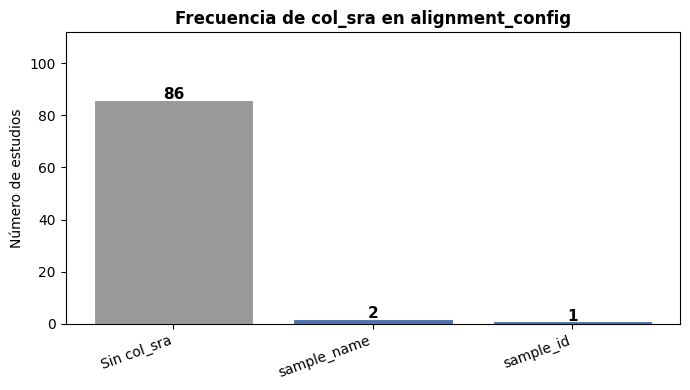

In [12]:
from collections import Counter
import matplotlib.pyplot as plt

# Extraer col_sra (los None se agrupan como "Sin col_sra")
col_sra_values = [r.get("col_sra") or "Sin col_sra" for r in rows]

counts = Counter(col_sra_values)
labels, values = zip(*counts.most_common())

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=["#4C72B0" if l != "Sin col_sra" else "#999" for l in labels],
              edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(val), ha="center", fontweight="bold", fontsize=11)

ax.set_ylabel("Número de estudios")
ax.set_title("Frecuencia de col_sra en alignment_config", fontweight="bold")
ax.set_ylim(0, max(values) * 1.3)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()